# Gateway landing (G) screen: where a concept lands early vs. how broadly it spreads

This notebook is a runnable demo of the experiment script `method.py` (plus the helper modules it imports:
`features.py`, `screen.py`, `next_field.py`, `report.py`). The code is the original code, split into cells, with
short explanations between them.

**What the experiment does.** It takes a frozen panel of 78 scientific concepts (P78). For each concept it has
yearly OpenAlex paper counts and the venue fields (26 OpenAlex fields) of the papers in three windows:
**A** = t0..t0+1, **B** = t0+2 and the outcome window **D** = t0+6..t0+8. It then asks one pre-registered question
(protocol **S0**):

> Does **G**, the *gateway centrality* of the off-home fields a concept lands in early (t0..t0+2), predict how broadly
> the concept later spreads across venue fields, beyond a simple 5-feature baseline **B5**?

* **G** = off-home-share-weighted eigenvector centrality of the adopting fields in a 26-field relatedness backbone
  (positive PMI of topic co-assignment, 1998-2002).
* **B5** = `[log_count_W5, growth_W5_B5, offhome_share_W3, entropy_W3, reach_W3]`.
* **Outcomes**: O1 sustained uptake (binary), **O2r** rarefied venue-field breadth at m=30/50 (primary, continuous),
  O3 transience (binary).
* **Test**: leave-one-home-group-out (CS / Eng / BGM / Med) ridge or logistic models, B5 vs B5+G, with a concept
  bootstrap giving Δρ (Spearman) or ΔAUC and a 90% CI. G *survives* if Δρ ≥ 0.10 with CI90 low > 0, it is positive in
  ≥3 of 4 groups, its split-half reliability is ≥ 0.6, and |ρ| with size is ≤ 0.6.
* Also: field-level retention (does the adopting field's gateway centrality predict that the concept stays there?),
  a next-field entry test (relatedness density vs field size), and a single-indicator table.

**Data.** The original script reads a frozen OpenAlex API cache (`cache/raw`, 44 MB) and a public sources snapshot
(~320 MB). This demo instead loads `mini_demo_data.json`, which holds the **output of `assemble()` and
`backbone.build()`**: the complete 78-concept panel and the 26-field backbone. Everything downstream is the
original code and uses the full panel, not a subsample. The config cell scales down only the bootstrap and
permutation counts. The original run used 2,000 bootstraps and 1,000 permutations and took about 5 minutes.

## Setup: install dependencies

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, sklearn, statsmodels, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'statsmodels==0.14.6',
         'matplotlib==3.10.0')

## Imports

This is the original `method.py` import block, plus the imports of its helper modules. `ROOT` is now the current
working directory instead of the script's folder. The imports of the helper modules (`oa_client`, `assemble`,
`backbone`, `features`, `next_field`, `screen`) are removed, because those modules are inlined as cells below. The
OpenAlex client and the `assemble()`/`build()` steps are replaced by the loaded data.

In [2]:
from __future__ import annotations

import json
import math
import resource
import sys
import time
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
from loguru import logger
from scipy.special import gammaln
from scipy.stats import norm, rankdata, spearmanr
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.discrete.conditional_models import ConditionalLogit

import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd()  # original: Path(__file__).resolve().parent
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "method.log", rotation="30 MB", level="DEBUG")
resource.setrlimit(resource.RLIMIT_AS, (12 * 1024 ** 3, 12 * 1024 ** 3))

## Data loading helper (GitHub URL, with a local fallback)

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8795ea-concepts-spread-once-adopters-make-them/fork/run_DVtwwCx0JbFq/round-1/experiment-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("concepts:", len(data["concepts"]), "| backbone fields:", len(data["backbone"]["fields"]))

Frozen P78 panel as produced by assemble() (78 concepts: yearly counts, per-window venue-field counts, homes, groups) plus the 26-field SLICE_A backbone produced by backbone.build(); both built offline from the artifact's frozen OpenAlex cache (cache/raw).
concepts: 78 | backbone fields: 26


## Config

These are all the tunable parameters. `N_BOOT`, `REFIT_BOOT` and `TRUNC_THR` are the module constants of
`method.py`. The other parameters were hard-coded numbers in the original code; they are named here so they can be
scaled down. The original full-run values are in the comments.

In [5]:
N_BOOT = 2000          # concept bootstrap resamples for every Delta-rho / Delta-AUC CI      (original: 2000)
REFIT_BOOT = 200       # stratified refit bootstrap for the primary O2r_m30 screen             (original: 200)
TRUNC_THR = 0.15       # outcome window counted as truncated if > 15% of papers fall outside the top-200 sources
MC_SIMS = 100_000      # Monte-Carlo draws that validate exact rarefaction                     (original: 100_000)
REL_N_SPLITS = 50      # random split-halves for the Spearman-Brown reliability                (original: 50)
NF_N_BOOT = 2000       # next-field entry: concept bootstrap of mean AUCs                      (original: 2000)
NF_N_PERM = 1000       # next-field entry: permutations of the backbone for the null           (original: 1000)
NF_CLOGIT_BOOT = 200   # next-field entry: cluster bootstrap of conditional-logit coefficients (original: 200)

## Helper module 1: `features.py`: indicators, G family and outcomes

These functions are copied unchanged from `features.py`:
* `rarefied_richness`: exact hypergeometric rarefaction. **O2r** is the expected number of distinct venue fields
  in a random draw of m = 30 (or 50) outcome-window papers.
* `shannon`, `kleinberg_batched` (burst weight), `cohort_split_half`.
* `Backbone`: wraps the 26-field backbone (PMI `phi`, `phi_min`, gateway centralities, field sizes).
* `g_family`: **G** and its secondaries (degree, betweenness and phi_min variants, `G_all`, `REL_home`,
  Rao-Stirling `RS`, domain shares, `GATEWAY_REACH`).
* `label_indicators` / `count_indicators`: the simple reference indicators (entropy, reach, off-home share,
  counts, share, growth, acceleration, burst).
* `outcomes`: O1 (mean share in t0+6..t0+8 ≥ share at t0+5), O3 (early peak followed by a ≥2x drop) and O2r.

In [6]:
HOME_DEV = {"CS": "Computer Science", "Eng": "Engineering",
            "BGM": "Biochemistry, Genetics and Molecular Biology", "Med": "Medicine"}


# ------------------------------------------------------------------ primitives
def rarefied_richness(counts: list[int] | np.ndarray, m: int) -> float:
    """Exact hypergeometric rarefaction E[S_m] = sum_j 1 - C(N-n_j, m)/C(N, m)."""
    n = np.asarray([c for c in counts if c > 0], dtype=float)
    N = n.sum()
    if N < m:
        return math.nan
    lc = lambda a, b: gammaln(a + 1) - gammaln(b + 1) - gammaln(a - b + 1)
    out = 0.0
    for nj in n:
        if N - nj < m:
            out += 1.0
        else:
            out += 1.0 - math.exp(lc(N - nj, m) - lc(N, m))
    return out


def shannon(c: dict) -> float:
    v = np.array([x for x in c.values() if x > 0], dtype=float)
    if v.sum() == 0:
        return math.nan
    p = v / v.sum()
    return float(-(p * np.log(p)).sum())


def kleinberg_batched(r: list[int], d: list[int], s: float = 2.0, gamma: float = 1.0) -> tuple[list[int], float]:
    """Kleinberg (2002) 2-state batched burst detection (own Viterbi). Returns states and burst weight."""
    r = np.asarray(r, float)
    d = np.asarray(d, float)
    n = len(r)
    p0 = r.sum() / d.sum()
    p1 = min(s * p0, 0.9999)

    def cost(p):
        return -(r * math.log(p) + (d - r) * math.log(1 - p))
    c = np.vstack([cost(p0), cost(p1)])
    trans = gamma * math.log(n)
    V = np.zeros((2, n))
    back = np.zeros((2, n), int)
    V[0, 0], V[1, 0] = c[0, 0], c[1, 0] + trans
    for t in range(1, n):
        for q in (0, 1):
            cand = [V[0, t - 1] + (trans if q == 1 else 0), V[1, t - 1]]
            back[q, t] = int(np.argmin(cand))
            V[q, t] = min(cand) + c[q, t]
    st = [int(np.argmin(V[:, -1]))]
    for t in range(n - 1, 0, -1):
        st.append(back[st[-1], t])
    st = st[::-1]
    weight = float(sum(c[0, t] - c[1, t] for t in range(n) if st[t] == 1))
    return st, weight


def cohort_split_half(mats: list[list[str]], fn, n_splits: int = 50, seed: int = 0) -> dict:
    """Split-half reliability across concepts: split each concept's paper-label list into random halves,
    compute fn(labels) per half, Spearman across concepts, Spearman-Brown corrected."""
    rng = np.random.default_rng(seed)
    rs = []
    for _ in range(n_splits):
        a, b = [], []
        for labels in mats:
            idx = rng.permutation(len(labels))
            h = len(labels) // 2
            a.append(fn([labels[i] for i in idx[:h]]))
            b.append(fn([labels[i] for i in idx[h:2 * h]]))
        a, b = np.array(a, float), np.array(b, float)
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() >= 5:
            r = spearmanr(a[ok], b[ok]).statistic
            if np.isfinite(r):
                rs.append(2 * r / (1 + r) if r > -1 else np.nan)
    rs = np.array(rs, float)
    if len(rs) == 0:
        return {"r_sb_median": math.nan, "p05": math.nan, "p95": math.nan, "n_splits": 0}
    return {"r_sb_median": float(np.nanmedian(rs)), "p05": float(np.nanpercentile(rs, 5)),
            "p95": float(np.nanpercentile(rs, 95)), "n_splits": int(len(rs))}


# ------------------------------------------------------------------ feature builders
class Backbone:
    def __init__(self, b: dict):
        self.fields = b["fields"]
        self.idx = {f: i for i, f in enumerate(self.fields)}
        self.phi = np.array(b["phi"])
        self.phi_min = np.array(b["phi_min"])
        self.gate = {k: np.array(b[k]) for k in ("gateway_eig", "gateway_deg", "gateway_btw", "gateway_eig_phimin")}
        self.domain = b["domain"]
        self.logsize = np.log(np.array(b["n_field"]))

    def g(self, f: str, kind: str = "gateway_eig") -> float:
        return float(self.gate[kind][self.idx[f]])


def g_family(fc: dict, home: list[str], bb: Backbone) -> dict:
    """G and secondaries from a field-count dict (labelled papers)."""
    tot = sum(fc.values())
    out = {}
    off = {f: n for f, n in fc.items() if f not in home and n > 0}
    offt = sum(off.values())
    for kind, nm in (("gateway_eig", "G"), ("gateway_deg", "G_deg"), ("gateway_btw", "G_btw"),
                     ("gateway_eig_phimin", "G_phimin")):
        out[nm] = sum(n * bb.g(f, kind) for f, n in off.items()) / offt if offt else math.nan
    out["G_all"] = sum(n * bb.g(f) for f, n in fc.items()) / tot if tot else math.nan
    hi = [bb.idx[h] for h in home if h in bb.idx]
    out["REL_home"] = (sum(n * np.mean([bb.phi[i, bb.idx[f]] for i in hi]) for f, n in off.items()) / offt
                       if offt and hi else math.nan)
    if tot:
        p = np.zeros(26)
        for f, n in fc.items():
            p[bb.idx[f]] = n / tot
        D = 1 - bb.phi_min
        np.fill_diagonal(D, 0)
        out["RS"] = float(p @ D @ p)
        for dom in ("Physical", "Life", "Health", "Social"):
            out[f"DOM_{dom}"] = float(sum(p[i] for i in range(26) if bb.domain[i] == dom))
    else:
        out["RS"] = math.nan
        for dom in ("Physical", "Life", "Health", "Social"):
            out[f"DOM_{dom}"] = math.nan
    top5 = set(np.argsort(bb.gate["gateway_eig"])[::-1][:5])
    out["GATEWAY_REACH"] = sum(1 for f, n in fc.items() if n >= 2 and bb.idx[f] in top5)
    return out


def g_from_labels(labels: list[str], home: list[str], bb: Backbone) -> float:
    return g_family(Counter(labels), home, bb)["G"]


def label_indicators(fc: dict, home: list[str], total: int) -> dict:
    lab = sum(fc.values())
    off = sum(n for f, n in fc.items() if f not in home)
    return {"entropy": shannon(fc) if lab else math.nan,
            "reach": sum(1 for n in fc.values() if n >= 2),
            "offhome_share": off / lab if lab else math.nan,
            "log_offhome_volume": math.log1p(off),
            "label_coverage": lab / total if total else math.nan}


def count_indicators(yc: dict, gtot: dict, t0: int, end: int) -> dict:
    ys = list(range(t0, end + 1))
    n = np.array([yc.get(y, 0) for y in ys], float)
    out = {"log_count": math.log1p(n.sum()), "share": n.sum() / sum(gtot[y] for y in ys) * 1e6,
           "growth": math.log((yc.get(end, 0) + 1) / (yc.get(t0 + 1, 0) + 1))}
    x = np.array(ys, float) - t0
    out["accel"] = float(np.polyfit(x, np.log1p(n), 2)[0]) if len(ys) >= 3 else math.nan
    yrs = list(range(t0 - 3, end + 1))
    _, w = kleinberg_batched([yc.get(y, 0) for y in yrs], [gtot[y] for y in yrs])
    out["burst"] = w
    return out


def outcomes(yc: dict, gtot: dict, t0: int, fcD: dict | None) -> dict:
    sh = lambda y: yc.get(y, 0) / gtot[y]
    o1 = int(np.mean([sh(y) for y in range(t0 + 6, t0 + 9)]) >= sh(t0 + 5))
    seq = [yc.get(y, 0) for y in range(t0, t0 + 9)]
    peak_y = t0 + int(np.argmax(seq))
    late = np.mean([yc.get(t0 + 7, 0), yc.get(t0 + 8, 0)])
    o3 = int(t0 + 3 <= peak_y <= t0 + 8 and max(seq) / max(late, 1e-9) >= 2)
    res = {"O1": o1, "O3": o3, "peak_year": peak_y}
    if fcD is not None:
        counts = list(fcD.values())
        N = int(sum(counts))
        res.update({"N_outcome": N, "O2r_m30": rarefied_richness(counts, 30),
                    "O2r_m50": rarefied_richness(counts, 50),
                    "O2_raw": int(sum(1 for c in counts if c >= 15))})
    else:
        res.update({"N_outcome": math.nan, "O2r_m30": math.nan, "O2r_m50": math.nan, "O2_raw": math.nan})
    return res

## Helper module 2: `screen.py`: the pre-registered S0 screen statistics

Copied unchanged from `screen.py`:
* `logo_predict`: **leave-one-home-group-out** out-of-fold predictions. It trains on 3 home groups and predicts the
  4th, using ridge (α=1) for continuous outcomes or logistic regression for binary ones. Missing values are
  median-imputed with the training-fold median.
* `paired_delta`: compares B5 with B5+G on the same OOF folds and bootstraps Δρ / ΔAUC over concepts. It also
  returns the per-group deltas and an optional stratified *refit* bootstrap.
* `loco_delta`: a supplementary leave-one-concept-out version.
* `dersimonian_laird`, `hanley_mcneil_var`, `single_indicator`: per-group and random-effects-pooled Spearman / AUC
  of one indicator at a time, with I².
* `field_level`: concept-clustered bootstrap for the field-retention model (rows = concept × off-home field).

In [7]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
GROUPS = ["CS", "Eng", "BGM", "Med"]


def _prep(X: pd.DataFrame, train: np.ndarray) -> np.ndarray:
    """Median-impute each column with the TRAINING-fold median (G's missing indicator is a separate column)."""
    X = X.copy()
    for c in X.columns:
        med = X.loc[train, c].median()
        X[c] = X[c].fillna(med if np.isfinite(med) else 0.0)
    return X.values.astype(float)


def logo_predict(df: pd.DataFrame, cols: list[str], y: str, kind: str = "ridge") -> np.ndarray:
    """Leave-one-home-group-out out-of-fold predictions."""
    oof = np.full(len(df), np.nan)
    g = df["group"].values
    for lg in GROUPS:
        te = g == lg
        tr = ~te
        if te.sum() == 0 or tr.sum() < 5:
            continue
        Xall = _prep(df[cols], tr)
        yt = df.loc[tr, y].values
        if kind == "ridge":
            m = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            m.fit(Xall[tr], yt)
            oof[te] = m.predict(Xall[te])
        else:
            if len(np.unique(yt)) < 2:
                oof[te] = yt.mean()
                continue
            m = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
            m.fit(Xall[tr], yt.astype(int))
            oof[te] = m.predict_proba(Xall[te])[:, 1]
    return oof


def _sp(a, b) -> float:
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 4 or np.std(a[ok]) == 0 or np.std(b[ok]) == 0:
        return math.nan
    return float(spearmanr(a[ok], b[ok]).statistic)


def _auc(y, p) -> float:
    ok = np.isfinite(p) & np.isfinite(y)
    if ok.sum() < 4 or len(np.unique(y[ok])) < 2:
        return math.nan
    return float(roc_auc_score(y[ok].astype(int), p[ok]))


def paired_delta(df: pd.DataFrame, base: list[str], cand: list[str], y: str, kind: str = "ridge",
                 n_boot: int = 2000, seed: int = 20260928, refit_boot: int = 0) -> dict:
    d = df[np.isfinite(df[y].values.astype(float))].reset_index(drop=True)
    ob = logo_predict(d, base, y, kind)
    oc = logo_predict(d, cand, y, kind)
    Y = d[y].values.astype(float)
    stat = _sp if kind == "ridge" else (lambda p, yy: _auc(yy, p))
    sb, sc = stat(ob, Y), stat(oc, Y)
    rng = np.random.default_rng(seed)
    n = len(d)
    boots = []
    for _ in range(n_boot):
        i = rng.integers(0, n, n)
        a, b = stat(ob[i], Y[i]), stat(oc[i], Y[i])
        if np.isfinite(a) and np.isfinite(b):
            boots.append(b - a)
    boots = np.array(boots)
    per = {}
    for g in GROUPS:
        m = d["group"].values == g
        pb, pc = stat(ob[m], Y[m]), stat(oc[m], Y[m])
        per[g] = {"n": int(m.sum()), "base": pb, "cand": pc,
                  "delta": (pc - pb) if np.isfinite(pb) and np.isfinite(pc) else math.nan}
    out = {"n": n, "metric": "spearman" if kind == "ridge" else "auc", "base": sb, "cand": sc, "delta": sc - sb,
           "ci90": [float(np.percentile(boots, 5)), float(np.percentile(boots, 95))] if len(boots) else [math.nan] * 2,
           "ci95": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))] if len(boots) else [math.nan] * 2,
           "p_boot_le0": float(np.mean(boots <= 0)) if len(boots) else math.nan,
           "per_group": per,
           "n_groups_positive": int(sum(1 for v in per.values() if np.isfinite(v["delta"]) and v["delta"] > 0)),
           "n_groups_evaluable": int(sum(1 for v in per.values() if np.isfinite(v["delta"]))),
           "oof_base": ob.tolist(), "oof_cand": oc.tolist(), "concepts": d["concept"].tolist()}
    if refit_boot:
        rr = []
        for _ in range(refit_boot):
            idx = np.concatenate([rng.choice(np.where(d["group"].values == g)[0], (d["group"].values == g).sum())
                                  for g in GROUPS if (d["group"].values == g).sum()])
            dd = d.iloc[idx].reset_index(drop=True)
            a = stat(logo_predict(dd, base, y, kind), dd[y].values.astype(float))
            b = stat(logo_predict(dd, cand, y, kind), dd[y].values.astype(float))
            if np.isfinite(a) and np.isfinite(b):
                rr.append(b - a)
        rr = np.array(rr)
        out["refit_boot"] = {"n": int(len(rr)), "ci90": [float(np.percentile(rr, 5)), float(np.percentile(rr, 95))]
                             if len(rr) else [math.nan] * 2, "mean": float(rr.mean()) if len(rr) else math.nan}
    return out


def loco_delta(df: pd.DataFrame, base: list[str], cand: list[str], y: str) -> dict:
    """Supplementary leave-one-concept-out ridge Delta-rho."""
    d = df[np.isfinite(df[y].values.astype(float))].reset_index(drop=True)
    res = {}
    for nm, cols in (("base", base), ("cand", cand)):
        oof = np.full(len(d), np.nan)
        for i in range(len(d)):
            tr = np.ones(len(d), bool)
            tr[i] = False
            X = _prep(d[cols], tr)
            m = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(X[tr], d.loc[tr, y].values)
            oof[i] = m.predict(X[~tr])[0]
        res[nm] = _sp(oof, d[y].values.astype(float))
    return {"base": res["base"], "cand": res["cand"], "delta": res["cand"] - res["base"], "n": len(d)}


# ------------------------------------------------------------------ meta-analysis
def dersimonian_laird(est: list[float], var: list[float]) -> dict:
    e = np.array(est, float)
    v = np.array(var, float)
    ok = np.isfinite(e) & np.isfinite(v) & (v > 0)
    e, v = e[ok], v[ok]
    k = len(e)
    if k < 2:
        return {"k": k, "pooled": float(e[0]) if k else math.nan, "se": math.nan, "tau2": math.nan, "I2": math.nan}
    w = 1 / v
    fe = (w * e).sum() / w.sum()
    Q = (w * (e - fe) ** 2).sum()
    C = w.sum() - (w ** 2).sum() / w.sum()
    tau2 = max(0.0, (Q - (k - 1)) / C) if C > 0 else 0.0
    ws = 1 / (v + tau2)
    re = (ws * e).sum() / ws.sum()
    se = math.sqrt(1 / ws.sum())
    I2 = max(0.0, (Q - (k - 1)) / Q) if Q > 0 else 0.0
    return {"k": k, "pooled": float(re), "se": float(se), "tau2": float(tau2), "I2": float(I2), "Q": float(Q)}


def hanley_mcneil_var(auc: float, n1: int, n0: int) -> float:
    q1, q2 = auc / (2 - auc), 2 * auc ** 2 / (1 + auc)
    return (auc * (1 - auc) + (n1 - 1) * (q1 - auc ** 2) + (n0 - 1) * (q2 - auc ** 2)) / (n1 * n0)


def single_indicator(df: pd.DataFrame, feat: str, y: str, binary: bool) -> dict:
    d = df[np.isfinite(df[y].values.astype(float)) & np.isfinite(df[feat].values.astype(float))]
    x, Y = d[feat].values.astype(float), d[y].values.astype(float)
    res = {"feature": feat, "outcome": y, "n": len(d)}
    if not binary:
        res["pooled"] = _sp(x, Y)
        ests, vars_, per = [], [], {}
        for g in GROUPS:
            m = d["group"].values == g
            r = _sp(x[m], Y[m])
            per[g] = r
            if np.isfinite(r) and m.sum() > 3:
                ests.append(math.atanh(max(min(r, 0.999), -0.999)))
                vars_.append(1.06 / (m.sum() - 3))
        dl = dersimonian_laird(ests, vars_)
        res.update({"per_group": per, "meta_pooled": math.tanh(dl["pooled"]) if np.isfinite(dl["pooled"]) else math.nan,
                    "meta_ci95": [math.tanh(dl["pooled"] - 1.96 * dl["se"]), math.tanh(dl["pooled"] + 1.96 * dl["se"])]
                    if np.isfinite(dl["se"]) else [math.nan] * 2, "I2": dl["I2"], "k": dl["k"],
                    "sign_consistency": int(sum(1 for v in per.values() if np.isfinite(v) and np.sign(v) ==
                                                np.sign(res["pooled"])))})
    else:
        res["pooled_raw"] = _auc(Y, x)
        per_raw, per_or, ests, vars_ = {}, {}, [], []
        for g in GROUPS:
            m = d["group"].values == g
            a = _auc(Y[m], x[m])
            per_raw[g] = a
            atr = _auc(Y[~m], x[~m])  # orientation chosen on training groups only
            sgn = 1 if (not np.isfinite(atr) or atr >= 0.5) else -1
            ao = a if sgn == 1 else (1 - a if np.isfinite(a) else a)
            per_or[g] = ao
            n1, n0 = int(Y[m].sum()), int((1 - Y[m]).sum())
            if np.isfinite(ao) and n1 and n0:
                aa = min(max(ao, 0.01), 0.99)
                ests.append(math.log(aa / (1 - aa)))
                vars_.append(hanley_mcneil_var(aa, n1, n0) / (aa * (1 - aa)) ** 2)
        dl = dersimonian_laird(ests, vars_)
        inv = lambda z: 1 / (1 + math.exp(-z))
        res.update({"per_group_raw": per_raw, "per_group_oriented": per_or,
                    "meta_pooled_oriented": inv(dl["pooled"]) if np.isfinite(dl["pooled"]) else math.nan,
                    "meta_ci95": [inv(dl["pooled"] - 1.96 * dl["se"]), inv(dl["pooled"] + 1.96 * dl["se"])]
                    if np.isfinite(dl["se"]) else [math.nan] * 2, "I2": dl["I2"], "k": dl["k"],
                    "sign_consistency": int(sum(1 for v in per_or.values() if np.isfinite(v) and v > 0.5))})
    return res


# ------------------------------------------------------------------ field level
def field_level(fr: pd.DataFrame, base: list[str], cand: list[str], n_boot: int = 2000, seed: int = 1) -> dict:
    d = fr.dropna(subset=["R"]).reset_index(drop=True)
    ob = logo_predict(d, base, "R", "logit")
    oc = logo_predict(d, cand, "R", "logit")
    Y = d["R"].values.astype(float)
    ab, ac = _auc(Y, ob), _auc(Y, oc)
    rng = np.random.default_rng(seed)
    cons = d["concept"].unique()
    rows = {c: np.where(d["concept"].values == c)[0] for c in cons}
    boots = []
    for _ in range(n_boot):
        pick = rng.choice(cons, len(cons))
        i = np.concatenate([rows[c] for c in pick])
        a, b = _auc(Y[i], ob[i]), _auc(Y[i], oc[i])
        if np.isfinite(a) and np.isfinite(b):
            boots.append(b - a)
    boots = np.array(boots)
    per = {}
    for g in GROUPS:
        m = d["group"].values == g
        per[g] = {"n_rows": int(m.sum()), "base": _auc(Y[m], ob[m]), "cand": _auc(Y[m], oc[m])}
    return {"n_rows": len(d), "n_concepts": len(cons), "prevalence": float(Y.mean()), "auc_base": ab, "auc_cand": ac,
            "delta_auc": ac - ab, "ci90": [float(np.percentile(boots, 5)), float(np.percentile(boots, 95))],
            "ci95": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))], "per_group": per}

## Helper module 3: `next_field.py`: relatedness-density next-field entry test

This applies the principle of relatedness (Hidalgo et al. 2007). Given the fields a concept already occupies (K),
the **density** of a new field k is the share of k's backbone ties that go to K. The test asks whether density
predicts which new field the concept enters next, and compares it with a field-size baseline. It uses
within-concept-step AUCs, a concept bootstrap, a conditional logit and a permutation null that shuffles the
backbone. The code is copied from `next_field.py` with one change: the conditional-logit bootstrap count (a
hard-coded `200` in the original) is now the parameter `n_clogit_boot`, so the config cell can set it.

In [8]:
def density(K: set[int], phi: np.ndarray) -> np.ndarray:
    den = phi.sum(axis=0)
    num = phi[list(K), :].sum(axis=0) if K else np.zeros(phi.shape[0])
    return np.where(den > 0, num / np.where(den > 0, den, 1), 0.0)


def build_rows(concepts: dict, bb) -> pd.DataFrame:
    """Steps: 'short' = A (t0..t0+1) -> t0+2 (cumulative >= 2 papers); 'long' = W3 -> outcome window (>= 3 papers)."""
    rows = []
    for nm, r in concepts.items():
        w = r.get("windows") or {}
        A, B, D = w.get("A"), w.get("B"), w.get("D")
        if not A or not B:
            continue
        cA = Counter(A["fields"])
        cW3 = cA + Counter(B["fields"])
        home_idx = [bb.idx[h] for h in r["home"] if h in bb.idx]
        steps = [("short", {bb.idx[f] for f, n in cA.items() if n >= 2},
                  lambda k: cW3.get(bb.fields[k], 0) >= 2)]
        if D:
            cD = Counter(D["fields"])
            steps.append(("long", {bb.idx[f] for f, n in cW3.items() if n >= 2},
                          lambda k, cD=cD: cD.get(bb.fields[k], 0) >= 3))
        for step, K, entered in steps:
            if not K:
                continue
            dens = density(K, bb.phi)
            for k in range(26):
                if k in K:
                    continue
                rows.append({"concept": nm, "group": r["group"], "step": step, "cs": f"{nm}|{step}",
                             "field": bb.fields[k], "k": k, "entered": int(entered(k)), "density": dens[k],
                             "log_size": bb.logsize[k],
                             "phi_home": float(np.mean([bb.phi[h, k] for h in home_idx])) if home_idx else 0.0})
    return pd.DataFrame(rows)


def per_cs_auc(df: pd.DataFrame, col: str) -> pd.Series:
    out = {}
    for cs, g in df.groupby("cs"):
        if g["entered"].nunique() == 2:
            out[cs] = roc_auc_score(g["entered"], g[col])
    return pd.Series(out)


def analyse(df: pd.DataFrame, bb, n_boot: int = 2000, n_perm: int = 1000, seed: int = 7,
            n_clogit_boot: int = 200) -> dict:  # n_clogit_boot: was a hard-coded 200 in the original
    rng = np.random.default_rng(seed)
    res = {"n_rows": len(df), "n_concept_steps": int(df["cs"].nunique()), "entry_rate": float(df["entered"].mean())}
    df = df.copy()
    df["dens_plus_size"] = np.nan
    for step in ("short", "long", "all"):
        d = df if step == "all" else df[df["step"] == step]
        if d.empty:
            continue
        a_den, a_size = per_cs_auc(d, "density"), per_cs_auc(d, "log_size")
        a_home = per_cs_auc(d, "phi_home")
        concepts = d["concept"].unique()

        def boot(series):
            idx = {c: [i for i in series.index if i.startswith(c + "|")] for c in concepts}
            bs = []
            for _ in range(n_boot):
                pick = rng.choice(concepts, len(concepts))
                vals = [series[i] for c in pick for i in idx[c]]
                if vals:
                    bs.append(np.mean(vals))
            return [float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))]
        entry = {"n_evaluable_concept_steps": int(len(a_den)),
                 "auc_density_mean": float(a_den.mean()), "auc_density_ci95": boot(a_den),
                 "auc_size_mean": float(a_size.mean()), "auc_size_ci95": boot(a_size),
                 "auc_phi_home_mean": float(a_home.mean()),
                 "density_minus_size_mean": float((a_den - a_size.reindex(a_den.index)).mean()),
                 "density_minus_size_ci95": boot(a_den - a_size.reindex(a_den.index))}
        per_group = {}
        for g, gg in d.groupby("group"):
            ad, asz = per_cs_auc(gg, "density"), per_cs_auc(gg, "log_size")
            per_group[g] = {"n": int(len(ad)), "auc_density": float(ad.mean()) if len(ad) else math.nan,
                            "auc_size": float(asz.mean()) if len(asz) else math.nan}
        entry["per_group"] = per_group
        # conditional logit with groups = concept-step
        try:
            dd = d[d["cs"].isin(a_den.index)]
            X = dd[["density", "log_size", "phi_home"]].values
            X = (X - X.mean(0)) / X.std(0)
            m = ConditionalLogit(dd["entered"].values, X, groups=dd["cs"].values).fit(disp=0)
            coefs = m.params.tolist()
            # cluster bootstrap of coefficients (resample concepts)
            cb = []
            for _ in range(n_clogit_boot):
                pick = rng.choice(dd["concept"].unique(), dd["concept"].nunique())
                parts = []
                for j, c in enumerate(pick):
                    p = dd[dd["concept"] == c].copy()
                    p["cs"] = p["cs"] + f"#{j}"
                    parts.append(p)
                bdf = pd.concat(parts)
                Xb = (bdf[["density", "log_size", "phi_home"]].values - dd[["density", "log_size", "phi_home"]].values.mean(0)) / dd[["density", "log_size", "phi_home"]].values.std(0)
                try:
                    cb.append(ConditionalLogit(bdf["entered"].values, Xb, groups=bdf["cs"].values).fit(disp=0).params)
                except (np.linalg.LinAlgError, ValueError):
                    continue
            cb = np.array(cb)
            entry["clogit"] = {"vars": ["density", "log_size", "phi_home"], "coef_std": coefs,
                               "ci95": [[float(np.percentile(cb[:, j], 2.5)), float(np.percentile(cb[:, j], 97.5))]
                                        for j in range(3)] if len(cb) else None,
                               "n_boot_ok": int(len(cb))}
            # AUC of combined score (density + size) from clogit linear predictor, within concept-step
            dd = dd.assign(lin=X @ np.array(coefs))
            entry["auc_combined_mean_in_sample"] = float(per_cs_auc(dd, "lin").mean())
        except (np.linalg.LinAlgError, ValueError) as e:
            entry["clogit"] = {"error": str(e)[:200]}
        # permutation null: shuffle field labels of phi
        null = []
        for _ in range(n_perm if step == "all" else 0):
            perm = rng.permutation(26)
            phip = bb.phi[np.ix_(perm, perm)]
            vals = []
            for cs, g in d.groupby("cs"):
                if g["entered"].nunique() < 2:
                    continue
                K = set(range(26)) - set(g["k"])
                dn = density(K, phip)
                vals.append(roc_auc_score(g["entered"], dn[g["k"].values]))
            null.append(np.mean(vals))
        if null:
            null = np.array(null)
            entry["perm_null"] = {"mean": float(null.mean()), "p95": float(np.percentile(null, 95)),
                                  "p_value": float((1 + (null >= a_den.mean()).sum()) / (1 + len(null))),
                                  "values": null.round(4).tolist()}
        res[step] = entry
    return res


# aliases used by method.py: `from next_field import analyse as nf_analyse, build_rows as nf_rows`
nf_analyse, nf_rows = analyse, build_rows

## Helper module 4: `report.py`: figures

This is copied from `report.py`. The only change is that the line `matplotlib.use("Agg")` is removed so the
notebook keeps its inline backend. The figures are saved to `figures/` and shown in the results section.

In [9]:
plt.rcParams.update({"font.size": 9, "pdf.fonttype": 42, "axes.spines.top": False, "axes.spines.right": False})


def _save(fig, out: Path, name: str) -> None:
    fig.tight_layout()
    fig.savefig(out / f"{name}.png", dpi=200)
    fig.savefig(out / f"{name}.pdf")
    plt.close(fig)


def make_figures(b: dict, sr: dict, si: pd.DataFrame, nf: dict, out: Path) -> None:
    out.mkdir(exist_ok=True)
    f = np.array(b["fields"])
    g = np.array(b["gateway_eig"])
    o = np.argsort(g)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.barh(f[o], g[o], color="#4C72B0")
    ax.set_xlabel("eigenvector gateway centrality (max = 1), positive-PMI backbone 1998-2002")
    _save(fig, out, "gateway_centrality")

    P = np.array(b["pmi"], float)
    P[P < -50] = np.nan
    np.fill_diagonal(P, np.nan)
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(P, cmap="RdBu_r", vmin=-3, vmax=3)
    ax.set_xticks(range(26), [x[:22] for x in f], rotation=90, fontsize=6)
    ax.set_yticks(range(26), [x[:22] for x in f], fontsize=6)
    fig.colorbar(im, ax=ax, label="PMI of topic co-assignment (1998-2002)")
    _save(fig, out, "relatedness_heatmap")

    d = sr["delta_rho_O2r_m30"]
    rows = [(gname, d["per_group"][gname]["delta"], d["per_group"][gname]["n"]) for gname in GROUPS]
    fig, ax = plt.subplots(figsize=(5, 3))
    y = np.arange(len(rows) + 1)
    vals = [r[1] if r[1] is not None else np.nan for r in rows]
    ax.scatter(vals, y[:-1], color="#DD8452")
    ax.errorbar([d["delta"]], [y[-1]], xerr=[[d["delta"] - d["ci90"][0]], [d["ci90"][1] - d["delta"]]],
                fmt="D", color="black", capsize=3)
    ax.axvline(0, color="grey", lw=0.8)
    ax.axvline(0.10, color="grey", lw=0.8, ls="--")
    ax.set_yticks(y, [f"{r[0]} (n={r[2]})" for r in rows] + ["pooled (90% CI)"])
    ax.set_xlabel("Δρ (B5+G − B5), O2r m=30, LOGO")
    _save(fig, out, "delta_rho_forest")

    for yname, col in (("O2r_m30", "raw_"), ("O1", "oriented_"), ("O3", "oriented_")):
        s = si[si.outcome == yname]
        M = s[[f"{col}{gname}" for gname in GROUPS]].values.astype(float)
        pooled = s["pooled_spearman" if yname == "O2r_m30" else "pooled_raw_auc"].values.astype(float)[:, None]
        M = np.hstack([M, pooled])
        fig, ax = plt.subplots(figsize=(5, 8))
        center, span = (0, 1) if yname == "O2r_m30" else (0.5, 0.5)
        im = ax.imshow(M, cmap="RdBu_r", vmin=center - span, vmax=center + span, aspect="auto")
        ax.set_yticks(range(len(s)), s["indicator"], fontsize=7)
        ax.set_xticks(range(5), GROUPS + ["pooled"])
        for i in range(M.shape[0]):
            for j in range(M.shape[1]):
                if np.isfinite(M[i, j]):
                    ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=6)
        fig.colorbar(im, ax=ax, label="Spearman" if yname == "O2r_m30" else "AUC (oriented on training groups)")
        ax.set_title(f"single indicators vs {yname}")
        _save(fig, out, f"single_indicator_heatmap_{yname}")

    pn = nf.get("all", {}).get("perm_null")
    if pn:
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.hist(pn["values"], bins=30, color="#bbbbbb", label="permuted phi (1,000)")
        ax.axvline(nf["all"]["auc_density_mean"], color="#C44E52", label="observed density AUC")
        ax.axvline(nf["all"]["auc_size_mean"], color="#4C72B0", ls="--", label="field-size baseline AUC")
        ax.set_xlabel("mean within concept-step AUC of next-field entry")
        ax.legend(fontsize=7)
        _save(fig, out, "next_field_auc_null")

## `method.py`: per-concept features and field-level rows

These functions are copied unchanged from `method.py`:
* `clean`: makes numpy values JSON-safe (NaN becomes `None`).
* `concept_features`: builds one feature row per concept from its window-A and window-B field counts
  (W3 = t0..t0+2) and its yearly counts. The row has the G family, `G_A` (G on t0..t0+1 only), the label
  indicators on W3, the count indicators on W3 and W5, `growth_W5_B5`, label coverage and the truncation flag.
* `field_rows`: one row per (concept, off-home field that has ≥5 labelled papers in W3). The target **R**
  (retention) is 1 if the field keeps ≥ half of its W3 share in the outcome window and has ≥9 papers there. The
  row also holds the field's gateway centrality, its relatedness to home and its relatedness density.

In [10]:
def clean(o):
    if isinstance(o, dict):
        return {str(k): clean(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [clean(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o


def concept_features(r: dict, bb: Backbone, gtot: dict) -> dict:
    t0 = int(r["t0"])
    w = r["windows"]
    A, B, D = w["A"], w["B"], w.get("D")
    fW3 = Counter(A["fields"]) + Counter(B["fields"])
    totW3 = A["total"] + B["total"]
    home = r["home"]
    f = {"concept": r["concept"]}
    gf = g_family(dict(fW3), home, bb)
    f.update({k: v for k, v in gf.items()})
    f["G_missing"] = int(not np.isfinite(gf["G"]))
    gA = g_family(dict(A["fields"]), home, bb)
    f["G_A"] = gA["G"]  # G on t0..t0+1 only (earlier landing)
    for k, v in label_indicators(dict(fW3), home, totW3).items():
        f[f"{k}_W3"] = v
    nA = sum(1 for n in A["fields"].values() if n >= 1)
    nBnew = sum(1 for fl, n in B["fields"].items() if n >= 1 and A["fields"].get(fl, 0) == 0)
    f["fields_gained_per_year_W3"] = (nA + nBnew) / 3
    for wn, end in (("W3", t0 + 2), ("W5", t0 + 4)):
        for k, v in count_indicators(r["yc"], gtot, t0, end).items():
            f[f"{k}_{wn}"] = v
    f["growth_W5_B5"] = math.log((r["yc"].get(t0 + 4, 0) + 1) / (r["yc"].get(t0 + 1, 0) + 1))
    f["label_coverage_early"] = f["label_coverage_W3"]
    f["label_coverage_outcome"] = (D["labelled"] / D["total"]) if D and D["total"] else math.nan
    f["trunc_share_outcome"] = D["truncated_share"] if D else math.nan
    f["trunc"] = int(D is not None and D["truncated_share"] > TRUNC_THR)
    return f


def field_rows(r: dict, bb: Backbone) -> list[dict]:
    w = r["windows"]
    A, B, D = w["A"], w["B"], w.get("D")
    if not D:
        return []
    fW3 = Counter(A["fields"]) + Counter(B["fields"])
    labW3, labD = sum(fW3.values()), sum(D["fields"].values())
    K = {bb.idx[x] for x, n in fW3.items() if n >= 2}
    home_idx = [bb.idx[h] for h in r["home"] if h in bb.idx]
    rows = []
    for j, n in fW3.items():
        if j in r["home"] or n < 5:
            continue
        k = bb.idx[j]
        Kj = K - {k}
        den = bb.phi[:, k].sum()
        dens = bb.phi[list(Kj), k].sum() / den if Kj and den > 0 else 0.0
        sW3 = n / labW3
        nD = D["fields"].get(j, 0)
        sD = nD / labD if labD else math.nan
        rows.append({"concept": r["concept"], "group": r["group"], "field": j, "n_W3": n, "n_A": A["fields"].get(j, 0),
                     "n_B": B["fields"].get(j, 0), "share_W3": sW3, "n_outcome": nD, "share_outcome": sD,
                     "R": int(sD >= 0.5 * sW3 and nD >= 9) if np.isfinite(sD) else math.nan,
                     "log_n_W3": math.log1p(n),
                     "growth_j": math.log((B["fields"].get(j, 0) + 1) / (A["fields"].get(j, 0) / 2 + 1)),
                     "gateway_j": bb.g(j), "phi_home_j": float(np.mean([bb.phi[h, k] for h in home_idx])),
                     "density_j": dens, "log_field_size": bb.logsize[k]})
    return rows

## `main()`, step 1: load the assembled panel and backbone, then build concept features

From here on the cells are the body of `method.py`'s `main()`, split into sections.

In the original, `data = assemble()` read the frozen API cache and `bdict = build_backbone()` rebuilt the backbone
from cached group-by calls. Both results are now in `data`. JSON turns integer dictionary keys into strings, so the
year keys of `yc` and `global_totals` are converted back to `int` here. That conversion is the only added line.
**Dev** concepts are those with status `dev` and pulled windows (46).

In [11]:
t_start = time.time()
logger.info("assembling cached data")
# original: data = assemble()  -> already loaded above from mini_demo_data.json
C = data["concepts"]
for r in C.values():  # JSON round-trip made the year keys strings; restore ints
    r["yc"] = {int(y): n for y, n in r["yc"].items()}
gtot = {int(y): n for y, n in data["meta"]["global_totals"].items()}
bdict = data["backbone"]  # original: bdict = build_backbone()
bb = Backbone(bdict)
(ROOT / "field_backbone.json").write_text(json.dumps(clean(bdict), indent=1))

dev = {k: v for k, v in C.items() if v["status"] == "dev" and v.get("windows")}
logger.info(f"dev concepts: {len(dev)}")
feats = pd.DataFrame([concept_features(r, bb, gtot) for r in dev.values()])
meta_cols = pd.DataFrame([{"concept": r["concept"], "group": r["group"], "t0": int(r["t0"]),
                           "newborn": bool(r["newborn"]), "thin_home": bool(r.get("thin_home")),
                           "home": ";".join(r["home"])} for r in dev.values()])
feats = meta_cols.merge(feats, on="concept")
feats.head()

21:11:20|INFO   |assembling cached data


21:11:20|INFO   |dev concepts: 46


,concept,group,t0,newborn,thin_home,home,G,G_deg,G_btw,G_phimin,...,log_count_W5,share_W5,growth_W5,accel_W5,burst_W5,growth_W5_B5,label_coverage_early,label_coverage_outcome,trunc_share_outcome,trunc
0,zinc finger nuclease,BGM,2005,True,False,"Biochemistry, Genetics and Molecular Biology",0.266077,0.706086,0.078889,0.513899,...,5.056246,6.952671,1.386294,0.129998,20.506692,1.386294,0.944444,0.822485,0.053254,0
1,sentiment analysis,CS,2007,True,False,Computer Science,0.101461,0.329143,0.031795,0.719380,...,5.834811,13.337820,1.623623,0.051614,53.681052,1.623623,0.411215,0.369413,0.525838,1
2,biosimilar,Med,2006,True,False,Medicine,0.290942,0.662264,0.088000,0.505959,...,6.021023,17.117582,0.768371,-0.036280,53.724165,0.768371,0.734694,0.458170,0.214230,1
3,smart grid,Eng,2008,True,False,Engineering,0.078918,0.275637,0.016938,0.729030,...,8.227643,138.172502,1.800493,-0.270079,764.073331,1.800493,0.603336,0.481387,0.446715,1
4,cancer stem cell,Med,2003,True,False,"Biochemistry, Genetics and Molecular Biology;M...",0.174826,0.428060,0.038611,0.483782,...,6.788972,45.741222,2.010449,-0.047719,195.783052,2.010449,0.826923,0.548817,0.339297,1


## Step 2: authoritative outcome table (all 78 rows) and field-level rows

This computes O1, O3 and O2r (m = 30 and 50) for every dev concept. `O2r_resid` is O2r_m30 residualised on the
log of the outcome-window size N, which takes out the part of breadth that just comes from having more papers.
The step writes `outcomes.csv`, `features.csv` and `field_outcomes.csv`.

In [12]:
# ---------------------------------------------------------------- outcomes (authoritative, all 78 rows)
orows = []
for nm, r in C.items():
    base = {"concept": nm, "panel_entry": r["panel_entry"], "aliases_used": "|".join(r["aliases_used"]),
            "intended_group": r["intended_group"], "t0": r["t0"], "newborn": r["newborn"], "status": r["status"],
            "dev": int(nm in dev), "home": ";".join(r.get("home", []) or []), "group": r.get("group")}
    if nm in dev:
        D = r["windows"].get("D")
        o = outcomes(r["yc"], gtot, int(r["t0"]), D["fields"] if D else None)
        f = feats.set_index("concept").loc[nm]
        base.update({"thin_home": r.get("thin_home"), "label_coverage_early": f["label_coverage_early"],
                     "label_coverage_outcome": f["label_coverage_outcome"],
                     "outcome_window_pulled": int(D is not None), "trunc_share_outcome": f["trunc_share_outcome"],
                     "trunc": int(f["trunc"]) if D else None, **o})
    orows.append(base)
out_df = pd.DataFrame(orows)
dmask = out_df["dev"] == 1
ok = dmask & out_df["O2r_m30"].notna()
X = np.log(out_df.loc[ok, "N_outcome"].astype(float).values)
yv = out_df.loc[ok, "O2r_m30"].astype(float).values
beta = np.polyfit(X, yv, 1)
out_df["O2r_resid"] = np.nan
out_df.loc[ok, "O2r_resid"] = yv - np.polyval(beta, X)
col_order = ["concept", "panel_entry", "aliases_used", "intended_group", "t0", "newborn", "status", "dev", "home",
             "group", "thin_home", "label_coverage_early", "label_coverage_outcome", "outcome_window_pulled",
             "trunc", "trunc_share_outcome", "N_outcome", "O1", "O2r_m30", "O2r_m50", "O2r_resid", "O2_raw",
             "O3", "peak_year"]
out_df = out_df[col_order]
out_df.to_csv(ROOT / "outcomes.csv", index=False)
logger.info(f"outcomes.csv rows={len(out_df)}; dev={int(dmask.sum())}; with O2r={int(ok.sum())}")

df = feats.merge(out_df[["concept", "O1", "O2r_m30", "O2r_m50", "O2r_resid", "O2_raw", "O3", "N_outcome"]],
                 on="concept")
df.to_csv(ROOT / "features.csv", index=False)

# ---------------------------------------------------------------- field-level rows
fr = pd.DataFrame([row for r in dev.values() for row in field_rows(r, bb)])
fr.to_csv(ROOT / "field_outcomes.csv", index=False)
print("field-level rows:", len(fr))

21:11:20|INFO   |outcomes.csv rows=78; dev=46; with O2r=34


field-level rows: 80


## Step 3: validations

This checks exact rarefaction against a Monte-Carlo estimate (`MC_SIMS` draws) for the first 3 concepts. It also
checks that O2r lies in [1, 26] and records the label coverage range and the API-vs-snapshot label agreement.

In [13]:
# ---------------------------------------------------------------- validations
val = {}
mc = {}
rng = np.random.default_rng(0)
for nm in list(df.dropna(subset=["O2r_m30"])["concept"])[:3]:
    counts = np.array([v for v in dev[nm]["windows"]["D"]["fields"].values() if v > 0])
    labels = np.repeat(np.arange(len(counts)), counts)
    sims = [len(np.unique(rng.choice(labels, 30, replace=False))) for _ in range(MC_SIMS)]  # original: 100_000
    mc[nm] = {"exact": rarefied_richness(counts, 30), "monte_carlo_1e5": float(np.mean(sims))}
val["rarefaction_vs_mc"] = mc
val["O2r_range_ok"] = bool(df["O2r_m30"].dropna().between(1, 26).all())
val["label_coverage_early_range"] = [float(df["label_coverage_early"].min()), float(df["label_coverage_early"].max())]
val["api_snapshot_label_agreement"] = data["meta"]["api_snapshot_label_agreement"]
val

{'rarefaction_vs_mc': {'zinc finger nuclease': {'exact': 3.7281670795026987,
   'monte_carlo_1e5': 3.72936},
  'sentiment analysis': {'exact': 4.2128386881461255,
   'monte_carlo_1e5': 4.20926},
  'biosimilar': {'exact': 4.8628335470214274, 'monte_carlo_1e5': 4.86104}},
 'O2r_range_ok': True,
 'label_coverage_early_range': [0.411214953271028, 0.9444444444444444],
 'api_snapshot_label_agreement': 0.999400479616307}

## Step 4: the primary screen, B5 vs B5+G

This runs `paired_delta` for the continuous outcomes (O2r_m30, which is the primary, plus O2r_m50 and O2r_resid)
with LOGO ridge, and for the binary outcomes O1 and O3 with LOGO logistic regression. A binary outcome is only
*evaluable* if its minority class has ≥5 concepts and it has positives in ≥2 groups.

In [14]:
# ---------------------------------------------------------------- screen
B5 = ["log_count_W5", "growth_W5_B5", "offhome_share_W3", "entropy_W3", "reach_W3"]
CAND = B5 + ["G", "G_missing"]
d2 = df.dropna(subset=["O2r_m30"]).reset_index(drop=True)
n_per_group = d2["group"].value_counts().to_dict()
logger.info(f"screen n={len(d2)} per group {n_per_group}")
scr = {}
for y in ("O2r_m30", "O2r_m50", "O2r_resid"):
    scr[y] = paired_delta(d2, B5, CAND, y, "ridge", N_BOOT, refit_boot=REFIT_BOOT if y == "O2r_m30" else 0)
    logger.info(f"{y}: base={scr[y]['base']:.3f} cand={scr[y]['cand']:.3f} delta={scr[y]['delta']:.3f} "
                f"ci90={scr[y]['ci90']}")
for y in ("O1", "O3"):
    scr[y] = paired_delta(df, B5, CAND, y, "logit", N_BOOT)
    pos = int(df[y].sum())
    grp_pos = df.groupby("group")[y].sum()
    scr[y]["n_positive"] = pos
    scr[y]["n_negative"] = int(len(df) - pos)
    scr[y]["positives_per_group"] = grp_pos.astype(int).to_dict()
    scr[y]["evaluable"] = bool(min(pos, len(df) - pos) >= 5 and (grp_pos > 0).sum() >= 2)
    if not scr[y]["evaluable"]:
        scr[y]["note"] = (f"not evaluable: only {min(pos, len(df) - pos)} concepts in the minority class "
                          f"(positives per group {grp_pos.astype(int).to_dict()}); LOGO training folds lack one "
                          "class, so AUCs are artefacts and are not interpreted")
    logger.info(f"{y}: base AUC={scr[y]['base']:.3f} cand={scr[y]['cand']:.3f} delta={scr[y]['delta']:.3f} "
                f"evaluable={scr[y]['evaluable']}")
scr["LOCO_O2r_m30"] = loco_delta(d2, B5, CAND, "O2r_m30")

21:11:23|INFO   |screen n=34 per group {'CS': 10, 'BGM': 9, 'Med': 8, 'Eng': 7}


21:11:28|INFO   |O2r_m30: base=0.327 cand=0.361 delta=0.033 ci90=[-0.09455114465232498, 0.1684260733483024]


21:11:29|INFO   |O2r_m50: base=0.349 cand=0.371 delta=0.023 ci90=[-0.11267950842308755, 0.16454355666014986]


21:11:30|INFO   |O2r_resid: base=0.394 cand=0.545 delta=0.150 ci90=[0.0002759913110042773, 0.32091171359862924]


21:11:32|INFO   |O1: base AUC=0.830 cand=0.902 delta=0.072 evaluable=True


21:11:33|INFO   |O3: base AUC=0.114 cand=0.114 delta=0.000 evaluable=False


## Step 5: reliability and size checks, then the pre-registered survival rule

**Split-half reliability.** Each concept's W3 paper labels are split into random halves. The feature is computed on
each half, and the Spearman correlation across concepts is Spearman-Brown corrected (`REL_N_SPLITS` splits).
`log_count_W5` uses binomial thinning instead. **Size check**: |ρ| of G with log count and with growth. Clauses
(i) to (iv) of the pre-registered S0 rule are then evaluated.

In [15]:
# reliability & size
home_of = {nm: dev[nm]["home"] for nm in d2["concept"]}
mats = [[fl for fl, n in (Counter(dev[nm]["windows"]["A"]["fields"]) +
                          Counter(dev[nm]["windows"]["B"]["fields"])).items() for _ in range(n)]
        for nm in df["concept"]]
homes_all = [dev[nm]["home"] for nm in df["concept"]]
rel = {}
for fname, fn in (("G", lambda labs, h: g_from_labels(labs, h, bb)),
                  ("G_all", lambda labs, h: g_family(Counter(labs), h, bb)["G_all"]),
                  ("RS", lambda labs, h: g_family(Counter(labs), h, bb)["RS"]),
                  ("REL_home", lambda labs, h: g_family(Counter(labs), h, bb)["REL_home"]),
                  ("entropy_W3", lambda labs, h: shannon(Counter(labs))),
                  ("offhome_share_W3", lambda labs, h: (sum(1 for x in labs if x not in h) / len(labs))
                   if labs else math.nan)):
    # pair each concept's labels with its home via closure over index
    vals = []
    rng2 = np.random.default_rng(11)
    rs = []
    for _ in range(REL_N_SPLITS):  # original: 50
        a, b = [], []
        for labs, h in zip(mats, homes_all):
            idx = rng2.permutation(len(labs))
            hh = len(labs) // 2
            a.append(fn([labs[i] for i in idx[:hh]], h))
            b.append(fn([labs[i] for i in idx[hh:2 * hh]], h))
        a, b = np.array(a, float), np.array(b, float)
        okk = np.isfinite(a) & np.isfinite(b)
        r_ = spearmanr(a[okk], b[okk]).statistic
        rs.append(2 * r_ / (1 + r_))
    rel[fname] = {"r_sb_median": float(np.median(rs)), "p05": float(np.percentile(rs, 5)),
                  "p95": float(np.percentile(rs, 95)), "n_splits": REL_N_SPLITS}
# count-only reliability via binomial thinning
rng3 = np.random.default_rng(12)
rsb = []
for _ in range(REL_N_SPLITS):  # original: 50
    a, b = [], []
    for nm in df["concept"]:
        r = dev[nm]
        t0 = int(r["t0"])
        ys = range(t0, t0 + 5)
        n = np.array([r["yc"][y] for y in ys])
        ha = rng3.binomial(n, 0.5)
        a.append(math.log1p(ha.sum()))
        b.append(math.log1p((n - ha).sum()))
    r_ = spearmanr(a, b).statistic
    rsb.append(2 * r_ / (1 + r_))
rel["log_count_W5"] = {"r_sb_median": float(np.median(rsb)), "method": "binomial thinning"}
size = {"G_vs_log_count_W5": float(spearmanr(df["G"], df["log_count_W5"], nan_policy="omit").statistic),
        "G_vs_growth_W5": float(spearmanr(df["G"], df["growth_W5_B5"], nan_policy="omit").statistic),
        "G_vs_label_coverage": float(spearmanr(df["G"], df["label_coverage_early"], nan_policy="omit").statistic)}
size["max_abs"] = max(abs(size["G_vs_log_count_W5"]), abs(size["G_vs_growth_W5"]))

prim = scr["O2r_m30"]
few = len(d2) < 25 or min(n_per_group.get(g, 0) for g in GROUPS) < 5
clauses = {"i_delta_ge_0.10_and_ci90_low_gt_0": bool(prim["delta"] >= 0.10 and prim["ci90"][0] > 0),
           "ii_positive_in_ge_3_of_4_groups": ("not evaluable" if few else bool(prim["n_groups_positive"] >= 3)),
           "iii_split_half_r_sb_ge_0.6": bool(rel["G"]["r_sb_median"] >= 0.6),
           "iv_max_abs_size_rho_le_0.6": bool(size["max_abs"] <= 0.6)}
survives = all(v is True for v in clauses.values())
print(json.dumps(clauses, indent=1), "\nsurvives:", survives)

{
 "i_delta_ge_0.10_and_ci90_low_gt_0": false,
 "ii_positive_in_ge_3_of_4_groups": false,
 "iii_split_half_r_sb_ge_0.6": true,
 "iv_max_abs_size_rho_le_0.6": true
} 
survives: False


## Step 6: sensitivity analyses and exploratory secondary screens

This reruns the primary screen on four subsets: newborn-only concepts, concepts without truncation, concepts
without a thin home, and concepts with label coverage ≥ 0.3. It also tries the gateway variants (degree,
phi_min eigenvector, betweenness, and G on t0..t0+1) and adds each secondary feature to B5 one at a time for O2r,
O1 and O3. These results are exploratory.

In [16]:
# sensitivities
sens = {}
subsets = {"newborn_only": d2["newborn"], "exclude_trunc": d2["trunc"] == 0, "exclude_thin_home": ~d2["thin_home"],
           "exclude_low_coverage_lt_0.3": d2["label_coverage_early"] >= 0.3}
for nm, m in subsets.items():
    dd = d2[m.values].reset_index(drop=True)
    if len(dd) >= 12 and dd["group"].nunique() >= 3:
        s = paired_delta(dd, B5, CAND, "O2r_m30", "ridge", N_BOOT)
        sens[nm] = {k: s[k] for k in ("n", "base", "cand", "delta", "ci90", "n_groups_positive")}
    else:
        sens[nm] = {"n": int(len(dd)), "note": "too few concepts for LOGO"}
for alt in ("G_deg", "G_phimin", "G_btw", "G_A"):
    dd = d2.copy()
    dd["G_alt_missing"] = dd[alt].isna().astype(int)
    s = paired_delta(dd, B5, B5 + [alt, "G_alt_missing"], "O2r_m30", "ridge", N_BOOT)
    sens[f"gateway_variant_{alt}"] = {k: s[k] for k in ("n", "base", "cand", "delta", "ci90", "n_groups_positive")}
sens["m50"] = {k: scr["O2r_m50"][k] for k in ("n", "base", "cand", "delta", "ci90", "n_groups_positive")}
hurdle = df[df["N_outcome"].notna() & (df["N_outcome"] < 30)]
sens["hurdle_N_lt_30"] = {"n": int(len(hurdle)), "O1_rate": float(hurdle["O1"].mean()) if len(hurdle) else None,
                          "O3_rate": float(hurdle["O3"].mean()) if len(hurdle) else None}

# secondaries one at a time (exploratory)
secondaries = ["G_all", "G_deg", "G_btw", "G_phimin", "G_A", "REL_home", "RS", "DOM_Physical", "DOM_Life",
               "DOM_Health", "DOM_Social", "GATEWAY_REACH"]
sec = {}
for s_ in secondaries:
    dd = d2.copy()
    dd["_miss"] = dd[s_].isna().astype(int)
    cols = B5 + [s_] + (["_miss"] if dd["_miss"].any() else [])
    r2 = paired_delta(dd, B5, cols, "O2r_m30", "ridge", N_BOOT)
    r1 = paired_delta(df.assign(_miss=df[s_].isna().astype(int)), B5, cols, "O1", "logit", N_BOOT)
    r3 = paired_delta(df.assign(_miss=df[s_].isna().astype(int)), B5, cols, "O3", "logit", N_BOOT)
    sec[s_] = {"label": "exploratory; not the pre-registered primary",
               "O2r_m30": {k: r2[k] for k in ("delta", "ci90", "n_groups_positive")},
               "O1": {k: r1[k] for k in ("delta", "ci90", "n_groups_positive")},
               "O3": {k: r3[k] for k in ("delta", "ci90", "n_groups_positive")}}
joint = B5 + ["G", "G_missing", "REL_home", "RS", "G_all"]
jd = d2.copy()
rj = paired_delta(jd, B5, joint, "O2r_m30", "ridge", N_BOOT)
sec["joint_B5+G+REL_home+RS+G_all"] = {"label": "exploratory joint composition model (insularity unavailable)",
                                       **{k: rj[k] for k in ("base", "cand", "delta", "ci90", "n_groups_positive")}}

## Step 7: field-level retention

Rows are (concept, adopting off-home field) pairs. The question is whether the adopting field's **gateway
centrality** (`gateway_j`), its relatedness to home and its relatedness density predict that the concept is retained
in that field. The baseline is the field-level volume, growth and share. A size-controlled version adds
`log_field_size`. The bootstrap is clustered by concept.

In [17]:
# field level
B_field = ["log_n_W3", "growth_j", "share_W3"]
fl = {"all_four_available": field_level(fr, B_field, B_field + ["gateway_j", "phi_home_j", "density_j"], N_BOOT)}
for c_ in ("gateway_j", "phi_home_j", "density_j"):
    fl[c_] = field_level(fr, B_field, B_field + [c_], N_BOOT)
fl["size_controlled_gateway_j"] = field_level(fr, B_field + ["log_field_size"],
                                               B_field + ["log_field_size", "gateway_j"], N_BOOT)
fl["size_controlled_all_three"] = field_level(fr, B_field + ["log_field_size"],
                                              B_field + ["log_field_size", "gateway_j", "phi_home_j", "density_j"],
                                              N_BOOT)
fl["log_field_size_alone_added"] = field_level(fr, B_field, B_field + ["log_field_size"], N_BOOT)
fl["note"] = "I_j (insularity) unavailable: shared key below floor before the insularity stage"

## Step 8: single-indicator table

For each of the 30 indicators and each outcome, this computes the pooled and per-group Spearman ρ (for O2r) or AUC
(for O1 and O3), and pools the per-group values with DerSimonian-Laird random effects, reporting I² and sign
consistency. The table is written to `single_indicators.csv`.

In [18]:
# single-indicator table
indicators = ["log_count_W3", "share_W3", "growth_W3", "accel_W3", "burst_W3", "log_count_W5", "share_W5",
              "growth_W5", "accel_W5", "burst_W5", "growth_W5_B5", "fields_gained_per_year_W3", "entropy_W3",
              "reach_W3", "offhome_share_W3", "log_offhome_volume_W3", "label_coverage_W3",
              "G", "G_A", "G_all", "G_deg", "G_btw", "G_phimin", "REL_home", "RS", "GATEWAY_REACH",
              "DOM_Physical", "DOM_Life", "DOM_Health", "DOM_Social"]
si_rows = []
si_full = []
for ind in indicators:
    for y, binary in (("O2r_m30", False), ("O1", True), ("O3", True)):
        base_df = d2 if y == "O2r_m30" else df
        r = single_indicator(base_df, ind, y, binary)
        si_full.append(r)
        row = {"indicator": ind, "family": "reference" if not ind.startswith(("G", "REL", "RS", "DOM"))
               else "G-family", "outcome": y, "n": r["n"]}
        if binary:
            row.update({"pooled_raw_auc": r["pooled_raw"], "meta_oriented_auc": r["meta_pooled_oriented"],
                        "meta_ci95_low": r["meta_ci95"][0], "meta_ci95_high": r["meta_ci95"][1], "I2": r["I2"],
                        "sign_consistency_k_of_4": r["sign_consistency"],
                        **{f"raw_{g}": r["per_group_raw"][g] for g in GROUPS},
                        **{f"oriented_{g}": r["per_group_oriented"][g] for g in GROUPS}})
        else:
            row.update({"pooled_spearman": r["pooled"], "meta_spearman": r["meta_pooled"],
                        "meta_ci95_low": r["meta_ci95"][0], "meta_ci95_high": r["meta_ci95"][1], "I2": r["I2"],
                        "sign_consistency_k_of_4": r["sign_consistency"],
                        **{f"raw_{g}": r["per_group"][g] for g in GROUPS}})
        si_rows.append(row)
si = pd.DataFrame(si_rows)
si.to_csv(ROOT / "single_indicators.csv", index=False)

## Step 9: next-field entry test

This is the slowest part of the original run: a bootstrap of the mean within-concept AUCs, a cluster bootstrap of
the conditional logit and a 1,000-permutation null. The iteration counts come from the config cell
(`NF_N_BOOT`, `NF_N_PERM`, `NF_CLOGIT_BOOT`). The original call was `nf_analyse(nfr, bb)` with the defaults
2000 / 1000 / 200.

In [19]:
# next-field entry
nfr = nf_rows(dev, bb)
nfr.to_csv(ROOT / "next_field_entry.csv", index=False)
nf = nf_analyse(nfr, bb, n_boot=NF_N_BOOT, n_perm=NF_N_PERM, n_clogit_boot=NF_CLOGIT_BOOT)
logger.info(f"next-field: all AUC density={nf['all']['auc_density_mean']:.3f} "
            f"size={nf['all']['auc_size_mean']:.3f} perm p={nf['all'].get('perm_null', {}).get('p_value')}")

21:15:20|INFO   |next-field: all AUC density=0.614 size=0.742 perm p=0.022977022977022976


## Step 10: assemble `screen_result`, draw figures, write `method_out.json`

This collects everything into `screen_result.json` and `method_out.json` (in the `exp_gen_sol_out` format, with
the per-concept out-of-fold predictions of the baseline and of B5+G) and draws the report figures. In the
original, `oa.credits_summary()` read the live OpenAlex credit ledger. Here the credits summary saved in the data
file is used instead.

In [20]:
# confirmation signals
conf = {"B5_alone_oof_spearman_O2r_positive": bool(prim["base"] > 0),
        "entropy_W3_positive_with_O2r": float(si[(si.indicator == "entropy_W3") & (si.outcome == "O2r_m30")]
                                              ["pooled_spearman"].iloc[0]),
        "reach_W3_positive_with_O2r": float(si[(si.indicator == "reach_W3") & (si.outcome == "O2r_m30")]
                                            ["pooled_spearman"].iloc[0])}

deviations = [
    "Shared OpenAlex key had ~2,180 credits left at start (five artifacts; reset ~11.7 h later). It fell below the "
    "1,000-credit floor at 12:26 after 286 credits used by this artifact; per plan all pulling stopped there.",
    "Per-year label pulls pooled into windows A=t0..t0+1, B=t0+2, C=t0+3..t0+4, D=t0+6..t0+8 (4 group_by calls "
    "per concept); only the top-200 sources per window were pulled (max_pages=1, degrade-ladder steps 3-4).",
    "Window C (t0+3..t0+4) was never pulled (floor reached): the label-based B5 components (off-home share, "
    "entropy, reach) use W3=t0..t0+2 instead of W5; log_count_W5 and growth_W5=log(n[t0+4]/n[t0+1]) use the free "
    "yearly counts as specified. Field-retention rows use W3 (>=5 labelled papers in t0..t0+2) and share_j(W3).",
    "Outcome window D pulled for 34 of 46 dev concepts (the first ones in the seeded order: an unbiased subset); "
    "O1 and O3 need only yearly counts and use all 46 dev concepts.",
    "Sources in D not looked up via the API before the floor were labelled with the same >=40% topic-profile rule "
    "from the free OpenAlex S3 sources snapshot (2026-09-23); API-vs-snapshot label agreement on the overlap: "
    f"{data['meta']['api_snapshot_label_agreement']:.4f}.",
    "Insularity I_j, phi_cit, SLICE_B, and the P5 primary_topic look were not computed (floor reached). INS "
    "features and the B5+G+INS joint model are absent; gateway sensitivities use weighted degree, betweenness "
    "and a phi_min (Hidalgo proximity) eigenvector instead of SLICE_B/phi_cit.",
    "Alias hygiene: 'NOTES' dropped, 'natural orifice translumenal endoscopic surgery' added (grounding_log.json).",
    "Probe anchors differ from the probe snapshot because S0 adds type:article|review,is_paratext:false "
    "(compressed sensing 2007: 37 vs 120 in the probe's unfiltered query); t0 shifts accordingly.",
    "Field retention '>=3 papers/year' operationalised as >=9 labelled papers pooled over t0+6..t0+8.",
    "Rao-Stirling uses d = 1 - phi_min (co-assignment proximity), not citation cosine.",
]

screen_result = {
    "candidate": "G_gateway_landing", "primary_feature": "G = off-home share-weighted eigenvector gateway "
    "centrality (SLICE_A positive-PMI topic co-assignment backbone) of venue fields adopting in t0..t0+2",
    "baseline": "B5 = [log_count_W5, growth log(n[t0+4]/n[t0+1]), offhome_share_W3, entropy_W3, reach_W3]",
    "n_used_O2r": int(len(d2)), "n_used_per_group_O2r": n_per_group,
    "n_used_O1_O3": int(len(df)), "n_used_per_group_O1_O3": df["group"].value_counts().to_dict(),
    "delta_rho_O2r_m30": {k: prim[k] for k in ("base", "cand", "delta", "ci90", "ci95", "p_boot_le0",
                                               "per_group", "n_groups_positive", "n_groups_evaluable",
                                               "refit_boot")},
    "per_group_signs": {g: (None if not np.isfinite(prim["per_group"][g]["delta"])
                            else int(np.sign(prim["per_group"][g]["delta"]))) for g in GROUPS},
    "reliability_split_half": rel, "size_correlations": size,
    "delta_auc_O1": {k: scr["O1"][k] for k in ("base", "cand", "delta", "ci90", "ci95", "per_group",
                                               "n_groups_positive", "n_positive", "positives_per_group",
                                               "evaluable")},
    "delta_auc_O3": {k: scr["O3"].get(k) for k in ("base", "cand", "delta", "ci90", "ci95", "per_group",
                                                   "n_groups_positive", "n_positive", "positives_per_group",
                                                   "evaluable", "note")},
    "delta_rho_O2r_m50": {k: scr["O2r_m50"][k] for k in ("base", "cand", "delta", "ci90", "n_groups_positive")},
    "delta_rho_O2r_resid": {k: scr["O2r_resid"][k] for k in ("base", "cand", "delta", "ci90",
                                                             "n_groups_positive")},
    "loco_supplementary": scr["LOCO_O2r_m30"],
    "survival_clauses": clauses, "survives": survives,
    "verdict": "SURVIVES" if survives else "DOES NOT SURVIVE the pre-registered S0 rule",
    "sensitivities": sens, "field_level": fl, "secondary_screens": sec,
    "confirmation_signals": conf, "status": "partial_data (credit floor); analysis complete on cached subset",
}
(ROOT / "screen_result.json").write_text(json.dumps(clean(screen_result), indent=1))

# ---------------------------------------------------------------- figures
try:
    make_figures(bdict, screen_result, si, nf, ROOT / "figures")  # original: import report; report.make_figures(...)
except (ImportError, ValueError, KeyError) as e:
    logger.error(f"figures failed: {e}")

# ---------------------------------------------------------------- method_out.json (exp_gen_sol_out)
def examples_for(y: str, res: dict, frame: pd.DataFrame) -> list[dict]:
    ob = dict(zip(res["concepts"], res["oof_base"]))
    oc = dict(zip(res["concepts"], res["oof_cand"]))
    ex = []
    for _, row in frame.iterrows():
        if row["concept"] not in ob:
            continue
        inp = {"concept": row["concept"], "t0": int(row["t0"]), "home": row["home"], "group": row["group"],
               **{c: (None if pd.isna(row[c]) else float(row[c])) for c in B5 + ["G", "G_missing"]}}
        ex.append({"input": json.dumps(inp), "output": str(row[y]),
                   "predict_baseline": f"{ob[row['concept']]:.6f}", "predict_our_method": f"{oc[row['concept']]:.6f}",
                   "metadata_group": row["group"], "metadata_fold": f"leave-out-{row['group']}",
                   "metadata_outcome": y, "metadata_newborn": bool(row["newborn"]),
                   "metadata_trunc": int(row["trunc"]) if not pd.isna(row["trunc"]) else None})
    return ex
datasets = [{"dataset": "P78_dev_O2r_m30_rarefied_venue_breadth", "examples": examples_for("O2r_m30", prim, d2)},
            {"dataset": "P78_dev_O1_sustained_uptake", "examples": examples_for("O1", scr["O1"], df)},
            {"dataset": "P78_dev_O3_transience", "examples": examples_for("O3", scr["O3"], df)}]
method_out = {"metadata": clean({
    "method_name": "G gateway-landing screen (S0) with authoritative outcome tables",
    "description": "Leave-one-home-group-out ridge/logistic of B5 vs B5+G on the P78 dev panel; 2,000 concept "
                   "bootstrap resamples; next-field relatedness-density entry test; single-indicator table.",
    "screen_result": {k: v for k, v in screen_result.items()},
    "next_field_entry": {k: ({kk: vv for kk, vv in v.items() if kk != "perm_null"} | (
        {"perm_null": {kk: vv for kk, vv in v["perm_null"].items() if kk != "values"}} if "perm_null" in v else {}))
        if isinstance(v, dict) else v for k, v in nf.items()},
    "single_indicator_table": si_rows,
    "backbone_summary": {"fields": bdict["fields"], "gateway_eig": bdict["gateway_eig"],
                         "gateway_eig_cv": bdict["gateway_eig_cv"], "n_positive_edges": bdict["n_positive_edges"],
                         "not_computed": bdict["not_computed"]},
    "p5_primary_topic_look": "not computed (shared key below the 1,000-credit floor)",
    "validations": val, "credits": data["credits_summary"], "deviations": deviations,  # original: oa.credits_summary()
    "runtime_s": round(time.time() - t_start, 1)}), "datasets": clean(datasets)}
(ROOT / "method_out.json").write_text(json.dumps(method_out, indent=1))
logger.info(f"done in {time.time() - t_start:.0f}s; verdict: {screen_result['verdict']}")

21:15:24|INFO   |done in 244s; verdict: DOES NOT SURVIVE the pre-registered S0 rule


## Results

The table below gives the headline numbers: the primary Δρ for O2r, the secondary outcomes, the survival
clauses, field-level retention and next-field entry. For reference, the original full run (2,000 bootstraps) gave
Δρ(O2r_m30) = +0.033 with CI90 [-0.095, 0.168], positive in 2 of 4 groups, so G **did not survive**. The same run
gave Δρ(O2r_resid) = +0.150, ΔAUC(O1) = +0.072, a field-level gateway ΔAUC of +0.10, and next-field density
AUC 0.61 vs field size 0.74. The point estimates here should match those exactly. The CIs and p-values match only
when the bootstrap counts in the config cell are at their original values.

                                    test  n    B5  B5+G  delta             CI90 groups +
                  Δρ  O2r m=30 (PRIMARY) 34 0.327 0.361 +0.033 [-0.095, +0.168]      2/4
                            Δρ  O2r m=50 34 0.349 0.371 +0.023 [-0.113, +0.165]      1/4
                 Δρ  O2r resid. on log N 34 0.394 0.545 +0.150 [+0.000, +0.321]      4/4
                          ΔAUC O1 uptake 46 0.830 0.902 +0.072 [+0.000, +0.163]      3/4
                      ΔAUC O3 transience 46 0.114 0.114 +0.000 [+0.000, +0.000]      0/1
       ΔAUC field retention: + gateway_j 80 0.705 0.808 +0.103 [+0.046, +0.154]         
ΔAUC field retention: + gateway_j | size 80 0.697 0.799 +0.102 [+0.041, +0.163]         

Survival clauses: {"i_delta_ge_0.10_and_ci90_low_gt_0": false, "ii_positive_in_ge_3_of_4_groups": false, "iii_split_half_r_sb_ge_0.6": true, "iv_max_abs_size_rho_le_0.6": true}
G split-half r_SB = 0.92 | max |rho| with size = 0.13
VERDICT: DOES NOT SURVIVE the pre-registered S0 rule
Nex

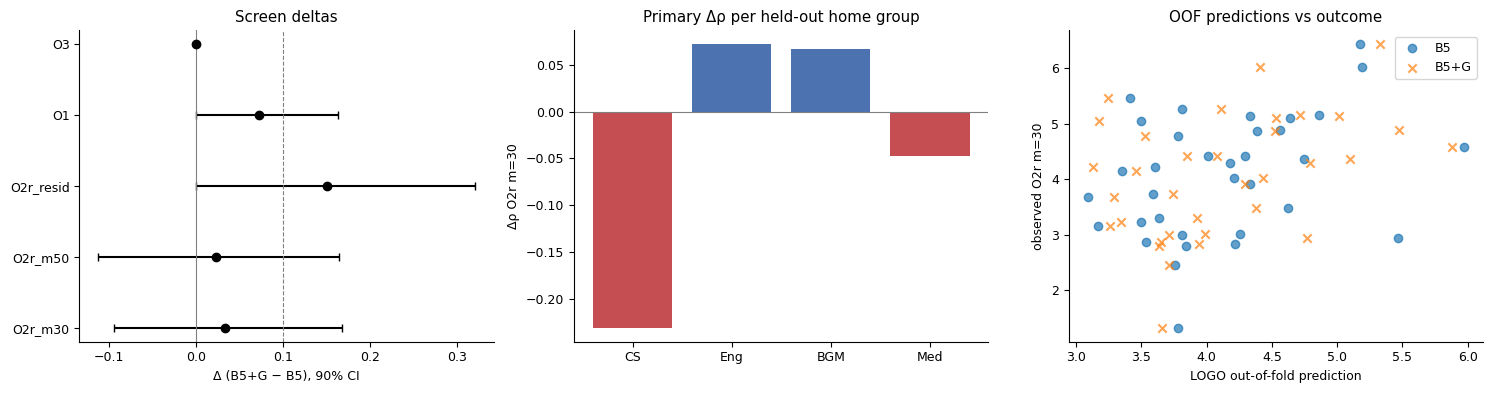

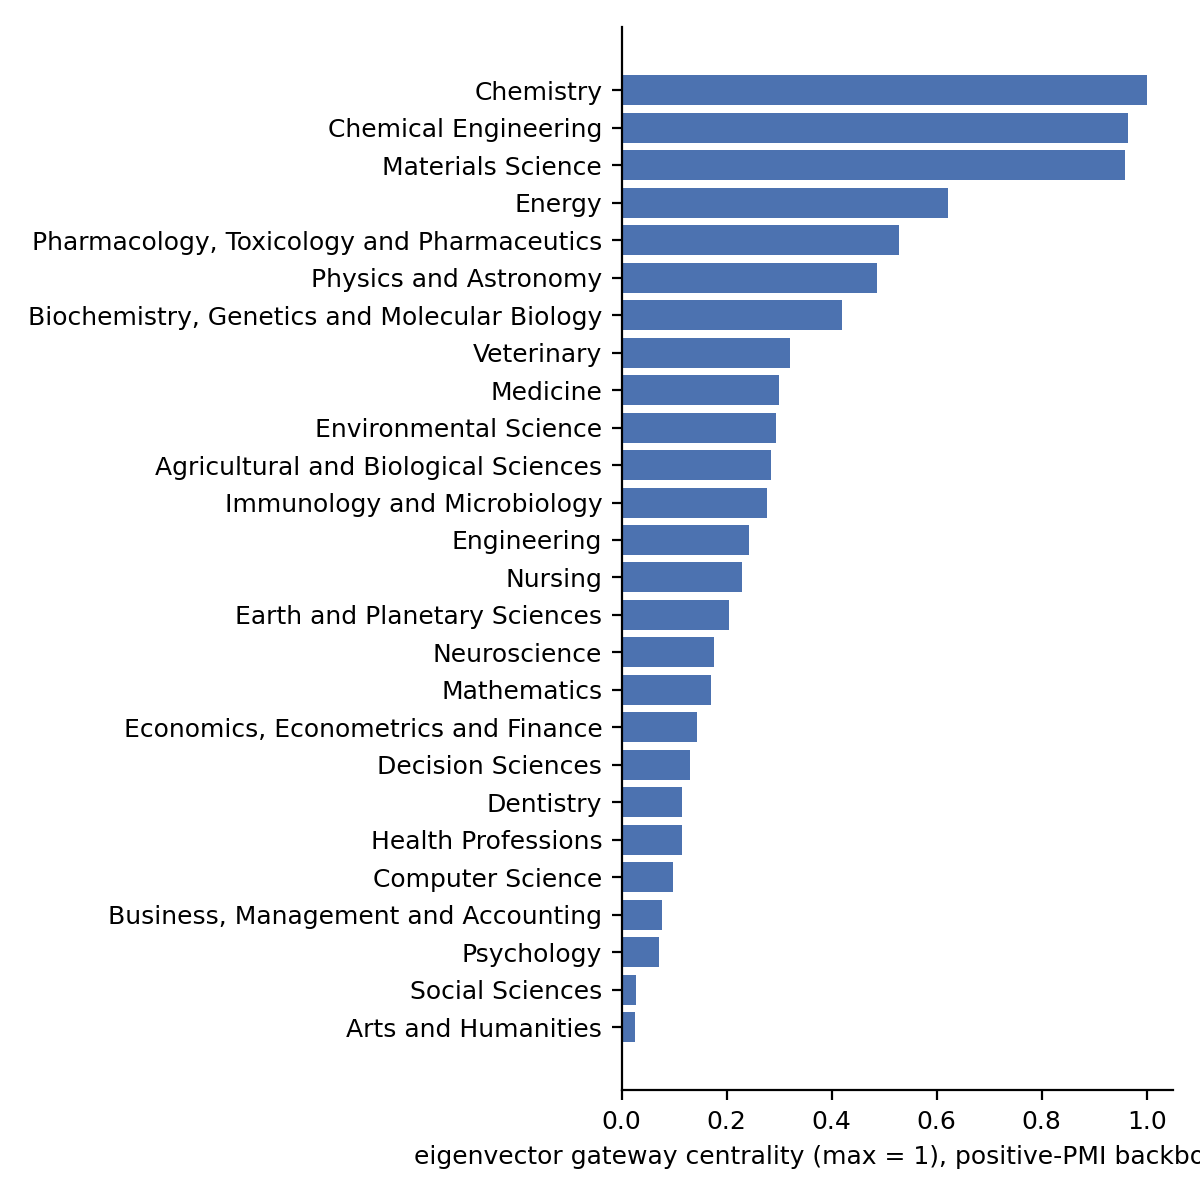

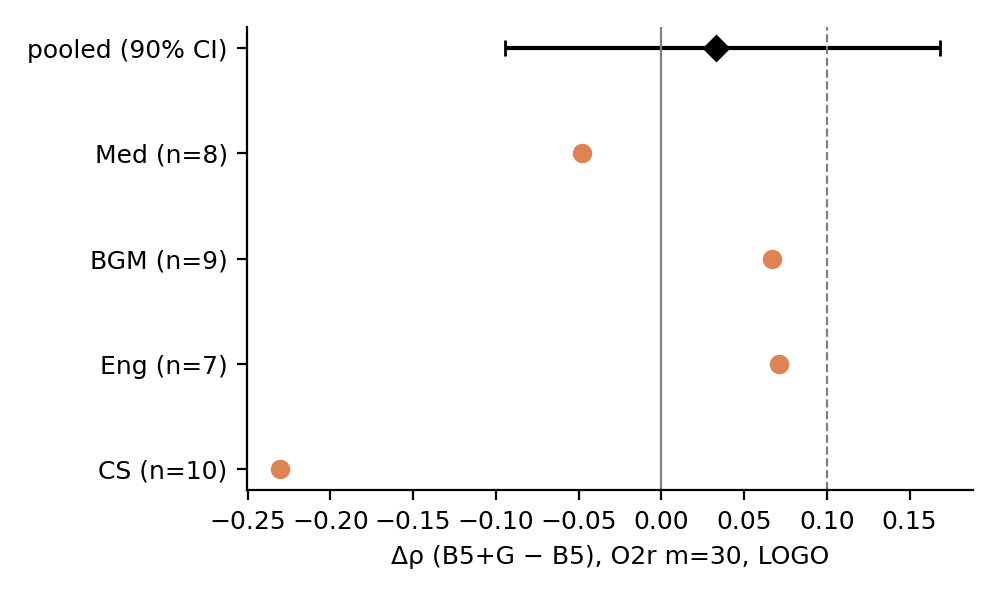

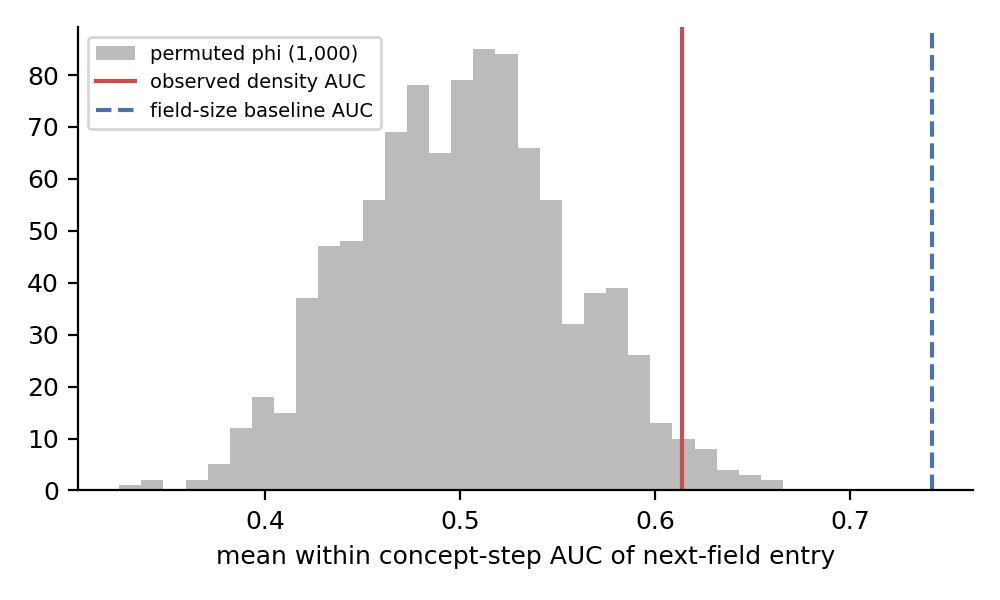

In [21]:
def _f(x, nd=3):
    return "n/a" if x is None or (isinstance(x, float) and not np.isfinite(x)) else f"{x:+.{nd}f}"

rows = []
for key, lab in (("O2r_m30", "Δρ  O2r m=30 (PRIMARY)"), ("O2r_m50", "Δρ  O2r m=50"),
                 ("O2r_resid", "Δρ  O2r resid. on log N"), ("O1", "ΔAUC O1 uptake"), ("O3", "ΔAUC O3 transience")):
    s = scr[key]
    rows.append({"test": lab, "n": s["n"], "B5": round(s["base"], 3), "B5+G": round(s["cand"], 3),
                 "delta": _f(s["delta"]), "CI90": f"[{_f(s['ci90'][0])}, {_f(s['ci90'][1])}]",
                 "groups +": f"{s['n_groups_positive']}/{s['n_groups_evaluable']}"})
for key, lab in (("gateway_j", "ΔAUC field retention: + gateway_j"),
                 ("size_controlled_gateway_j", "ΔAUC field retention: + gateway_j | size")):
    s = fl[key]
    rows.append({"test": lab, "n": s["n_rows"], "B5": round(s["auc_base"], 3), "B5+G": round(s["auc_cand"], 3),
                 "delta": _f(s["delta_auc"]), "CI90": f"[{_f(s['ci90'][0])}, {_f(s['ci90'][1])}]", "groups +": ""})
summary = pd.DataFrame(rows)
print(summary.to_string(index=False))
print("\nSurvival clauses:", json.dumps(clauses))
print("G split-half r_SB = %.2f | max |rho| with size = %.2f" % (rel["G"]["r_sb_median"], size["max_abs"]))
print("VERDICT:", screen_result["verdict"])
print("Next-field entry: density AUC %.3f vs log-field-size AUC %.3f, permutation p = %s" % (
    nf["all"]["auc_density_mean"], nf["all"]["auc_size_mean"], nf["all"].get("perm_null", {}).get("p_value")))

# ---- summary plots: per-group Delta-rho for the primary, and OOF predictions vs outcome
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ax = axes[0]
labs = ["O2r_m30", "O2r_m50", "O2r_resid", "O1", "O3"]
dl = [scr[k]["delta"] for k in labs]
lo = [scr[k]["delta"] - scr[k]["ci90"][0] for k in labs]
hi = [scr[k]["ci90"][1] - scr[k]["delta"] for k in labs]
ax.errorbar(dl, range(len(labs)), xerr=[lo, hi], fmt="o", color="black", capsize=3)
ax.axvline(0, color="grey", lw=0.8); ax.axvline(0.10, color="grey", ls="--", lw=0.8)
ax.set_yticks(range(len(labs)), labs); ax.set_xlabel("Δ (B5+G − B5), 90% CI"); ax.set_title("Screen deltas")
ax = axes[1]
pg = prim["per_group"]
ax.bar(GROUPS, [pg[g]["delta"] for g in GROUPS], color=["#4C72B0" if pg[g]["delta"] > 0 else "#C44E52" for g in GROUPS])
ax.axhline(0, color="grey", lw=0.8); ax.set_ylabel("Δρ O2r m=30"); ax.set_title("Primary Δρ per held-out home group")
ax = axes[2]
Yp = np.array([v for v in d2.set_index("concept").loc[prim["concepts"], "O2r_m30"]], float)
ax.scatter(prim["oof_base"], Yp, label="B5", alpha=0.7)
ax.scatter(prim["oof_cand"], Yp, label="B5+G", alpha=0.7, marker="x")
ax.set_xlabel("LOGO out-of-fold prediction"); ax.set_ylabel("observed O2r m=30"); ax.legend()
ax.set_title("OOF predictions vs outcome")
plt.tight_layout(); plt.show()

# ---- the figures written by report.make_figures
for name in ("gateway_centrality", "delta_rho_forest", "next_field_auc_null"):
    p = ROOT / "figures" / f"{name}.png"
    if p.exists():
        display(Image(filename=str(p), width=520))